<a href="https://colab.research.google.com/github/pedro-cantarutti/pos-puc-ml-analytics/blob/main/mvp3_puc_ml_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP 3 - Machine Learning & Analytics

## Classificação de Tumores de Mama com Machine Learning

**Aluno:** Pedro Cantarutti  
**Curso:** Pós PUC  
**Tipo de problema:** Classificação supervisionada binária  
**Dataset:** Breast Cancer Wisconsin Diagnostic Dataset  

Este notebook apresenta um MVP individual de Machine Learning & Analytics. O objetivo é construir, avaliar e discutir uma solução de aprendizado de máquina para classificar tumores de mama como **benignos** ou **malignos** a partir de atributos numéricos extraídos de imagens de punção aspirativa por agulha fina.

O foco deste MVP não é obter o modelo mais complexo possível, mas sim demonstrar um fluxo completo, coerente, reproduzível e tecnicamente justificado de Machine Learning.

## 1. Definição do problema

O problema escolhido é a **classificação de tumores de mama** em duas classes: benigno ou maligno.

O objetivo do modelo é utilizar características numéricas dos núcleos celulares, extraídas de imagens digitalizadas de exames de punção aspirativa, para prever se determinado tumor apresenta diagnóstico benigno ou maligno.

Este é um problema adequado para Machine Learning porque existe uma base histórica rotulada, na qual cada observação contém atributos mensuráveis e uma classe conhecida. A partir desses exemplos, algoritmos supervisionados podem aprender padrões associados a cada diagnóstico e depois generalizar para novos casos.

### Tipo de tarefa

- **Tipo de problema:** classificação supervisionada binária.
- **Variável-alvo:** diagnóstico do tumor.
- **Classe positiva adotada neste trabalho:** tumor maligno.

### Premissas e restrições

As principais premissas deste MVP são:

1. Os dados utilizados são representativos o suficiente para demonstrar o fluxo de modelagem.
2. O objetivo é educacional e analítico, não clínico.
3. O modelo não deve ser interpretado como ferramenta médica real sem validação especializada.
4. A divisão entre treino e teste deve evitar vazamento de dados.
5. As transformações de pré-processamento devem ser ajustadas apenas nos dados de treino, quando aplicável.
6. Como falsos negativos podem ser mais graves nesse contexto, o recall da classe maligna receberá atenção especial na avaliação.

## 2. Apresentação dos dados

O dataset utilizado é o **Breast Cancer Wisconsin Diagnostic Dataset**, originalmente disponibilizado pelo UCI Machine Learning Repository e também incluído em bibliotecas públicas de Machine Learning.

A base contém características calculadas a partir de imagens digitalizadas de punção aspirativa por agulha fina de massas mamárias. Essas características descrevem propriedades dos núcleos celulares presentes nas imagens, como raio, textura, perímetro, área, suavidade, compacidade, concavidade, simetria e dimensão fractal.

### Critério de escolha do dataset

Este dataset foi escolhido porque:

- é público e amplamente utilizado em problemas de classificação;
- possui tamanho adequado para um MVP executável rapidamente no Google Colab;
- não exige login, token, chave de API ou upload manual;
- contém variável-alvo clara;
- permite comparar modelos simples e não lineares;
- permite discutir métricas relevantes, como recall, precisão, F1-score e ROC-AUC.

### Observação sobre a entrega

Para manter o notebook reproduzível, os dados são carregados a partir de uma URL pública. Caso a entrega da disciplina exija que o dataset esteja no mesmo repositório GitHub do notebook, basta subir o CSV no repositório e substituir a variável `DATA_URL` na célula de carregamento.

In [ ]:
# ============================================================
# 1. Importação das bibliotecas
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
# ============================================================
# 2. Carregamento dos dados
# ============================================================

# URL pública do dataset.
DATA_URL = "https://huggingface.co/datasets/scikit-learn/breast-cancer-wisconsin/resolve/main/breast_cancer.csv"

def load_dataset(data_url: str) -> pd.DataFrame:
    # Carrega o dataset a partir de uma URL pública.
    # Se houver falha temporária de conexão, utiliza a cópia pública do scikit-learn como fallback.
    try:
        df_loaded = pd.read_csv(data_url)
        print(f"Dataset carregado a partir da URL pública:\n{data_url}")
    except Exception as error:
        print("Não foi possível carregar a URL pública.")
        print(f"Erro encontrado: {error}")
        print("Usando fallback público do scikit-learn para manter o notebook executável.")
        dataset = load_breast_cancer(as_frame=True)
        df_loaded = dataset.frame.copy()

    return df_loaded

df_raw = load_dataset(DATA_URL)
df_raw.head()

Dataset carregado a partir da URL pública:
https://huggingface.co/datasets/scikit-learn/breast-cancer-wisconsin/resolve/main/breast_cancer.csv


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
# ============================================================
# 3. Padronização da estrutura dos dados
# ============================================================

df = df_raw.copy()

# Remove colunas de índice ou identificadores, se existirem.
cols_to_drop = [col for col in df.columns if col.lower().startswith("unnamed") or col.lower() == "id"]
df = df.drop(columns=cols_to_drop, errors="ignore")

# Padroniza o nome da variável-alvo.
if "target" in df.columns and "diagnosis" not in df.columns:
    df = df.rename(columns={"target": "diagnosis"})

# Se a base vier com diagnóstico textual ou no formato M/B, padronizamos.
if df["diagnosis"].dtype == "object":
    diagnosis_map = {
        "M": "malignant",
        "B": "benign",
        "malignant": "malignant",
        "benign": "benign",
        "Malignant": "malignant",
        "Benign": "benign"
    }
    df["diagnosis_label"] = df["diagnosis"].map(diagnosis_map)
else:
    # No sklearn, target 0 = malignant e target 1 = benign.
    df["diagnosis_label"] = df["diagnosis"].map({0: "malignant", 1: "benign"})

# Cria alvo binário: 1 = maligno, 0 = benigno.
df["target_malignant"] = df["diagnosis_label"].map({"malignant": 1, "benign": 0})

# Remove linhas com alvo inválido, caso existam.
df = df.dropna(subset=["target_malignant"]).copy()
df["target_malignant"] = df["target_malignant"].astype(int)

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_label,target_malignant
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant,1


## 3. Análise exploratória inicial

Nesta etapa, o objetivo é compreender a estrutura da base antes da modelagem. Serão avaliados:

- quantidade de registros e atributos;
- tipos das variáveis;
- presença de valores ausentes;
- estatísticas descritivas;
- distribuição da variável-alvo;
- correlação entre atributos;
- possíveis sinais de desbalanceamento.

In [ ]:
# Dimensão do dataset
print(f"Quantidade de registros: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de registros: 569
Quantidade de colunas: 33


In [ ]:
# Primeiras linhas
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_label,target_malignant
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant,1


In [ ]:
# Informações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [ ]:
# Estatísticas descritivas dos atributos numéricos
df.describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [ ]:
# Verificação de valores ausentes
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

,0


In [ ]:
# Distribuição da variável-alvo
target_counts = df["diagnosis_label"].value_counts()
target_percent = df["diagnosis_label"].value_counts(normalize=True) * 100

target_distribution = pd.DataFrame({
    "quantidade": target_counts,
    "percentual": target_percent.round(2)
})

target_distribution

,quantidade,percentual
diagnosis_label,,
benign,357,62.74
malignant,212,37.26


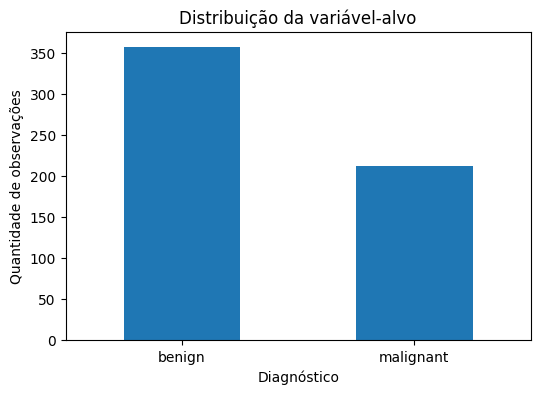

In [ ]:
# Gráfico da distribuição da variável-alvo
plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Distribuição da variável-alvo")
plt.xlabel("Diagnóstico")
plt.ylabel("Quantidade de observações")
plt.xticks(rotation=0)
plt.show()

A distribuição da variável-alvo permite verificar se há desbalanceamento relevante entre as classes. Como este é um problema de classificação binária, esse ponto é importante porque uma base muito desbalanceada poderia fazer a acurácia parecer artificialmente boa.

Neste problema, além da acurácia, serão usadas métricas como **recall**, **precisão**, **F1-score** e **ROC-AUC**.

In [ ]:
# Seleciona apenas as variáveis preditoras numéricas
feature_columns = [
    col for col in df.columns
    if col not in ["diagnosis", "diagnosis_label", "target_malignant"]
]

X_full = df[feature_columns].copy()
y_full = df["target_malignant"].copy()

print(f"Quantidade de atributos preditores: {X_full.shape[1]}")
X_full.head()

Quantidade de atributos preditores: 30


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# Correlação entre algumas variáveis e o alvo
corr_with_target = df[feature_columns + ["target_malignant"]].corr(numeric_only=True)["target_malignant"]
corr_with_target = corr_with_target.drop("target_malignant").sort_values(key=abs, ascending=False)

corr_with_target.head(10)

,target_malignant
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360
concavity_worst,0.659610


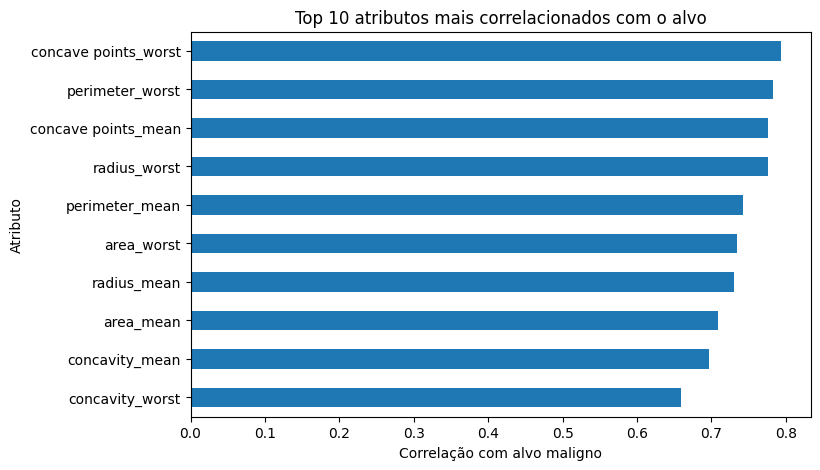

In [ ]:
# Gráfico com as 10 variáveis mais correlacionadas com o alvo em valor absoluto
top_corr = corr_with_target.head(10).sort_values()

plt.figure(figsize=(8, 5))
top_corr.plot(kind="barh")
plt.title("Top 10 atributos mais correlacionados com o alvo")
plt.xlabel("Correlação com alvo maligno")
plt.ylabel("Atributo")
plt.show()

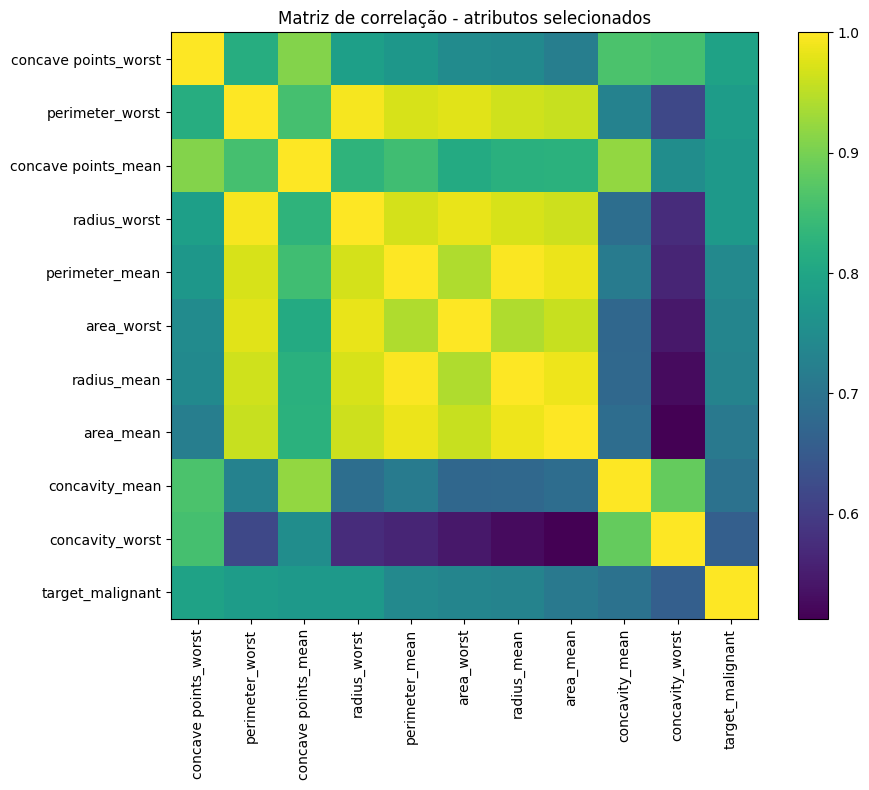

In [ ]:
# Matriz de correlação reduzida para as variáveis mais correlacionadas
selected_corr_features = corr_with_target.head(10).index.tolist()
corr_matrix = df[selected_corr_features + ["target_malignant"]].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Matriz de correlação - atributos selecionados")
plt.tight_layout()
plt.show()

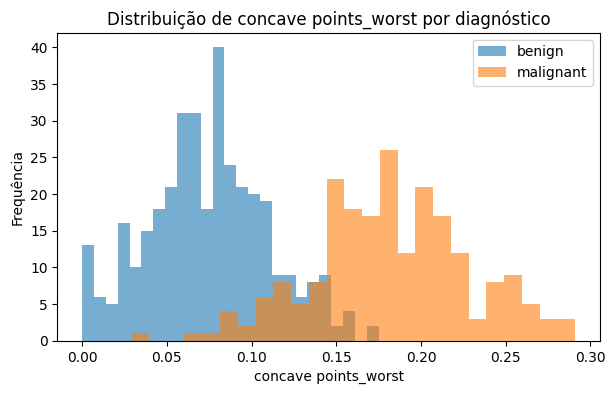

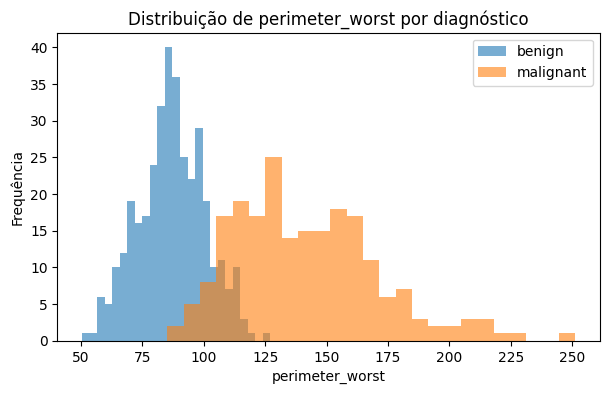

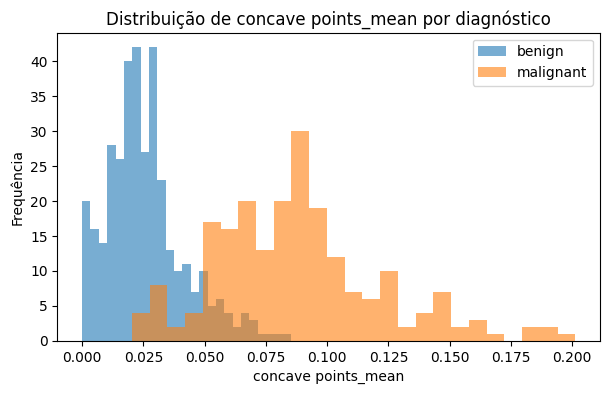

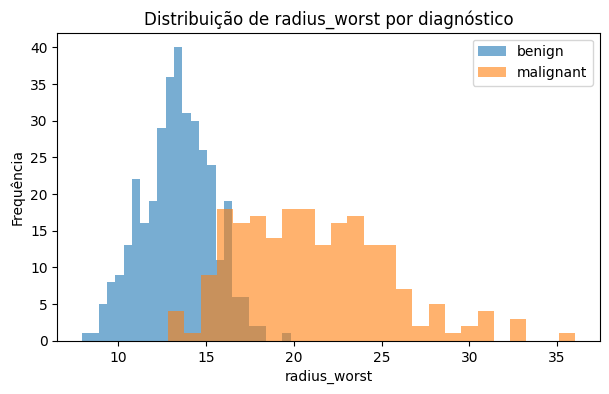

In [ ]:
# Histogramas de alguns atributos importantes
features_to_plot = corr_with_target.head(4).index.tolist()

for feature in features_to_plot:
    plt.figure(figsize=(7, 4))
    for label in ["benign", "malignant"]:
        subset = df[df["diagnosis_label"] == label]
        plt.hist(subset[feature], alpha=0.6, bins=25, label=label)
    plt.title(f"Distribuição de {feature} por diagnóstico")
    plt.xlabel(feature)
    plt.ylabel("Frequência")
    plt.legend()
    plt.show()

## 4. Preparação dos dados

Como as variáveis preditoras são numéricas, não há necessidade de codificação de variáveis categóricas.

As principais decisões de preparação foram:

1. Remover colunas de identificação ou índice, caso existam.
2. Padronizar a variável-alvo para formato binário.
3. Separar atributos preditores (`X`) e variável-alvo (`y`).
4. Aplicar padronização com `StandardScaler` dentro de pipelines para os modelos sensíveis à escala.

A padronização é importante para modelos como Regressão Logística e SVM, pois esses algoritmos são afetados pela escala das variáveis. O Random Forest, por outro lado, não depende fortemente da escala, mas foi mantido em pipeline para organização do fluxo.

Para evitar vazamento de dados, o `StandardScaler` será ajustado apenas nos dados de treino dentro do pipeline.

In [ ]:
# Separação entre atributos e alvo
X = X_full.copy()
y = y_full.copy()

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (569, 30)
Shape de y: (569,)


## 5. Divisão dos dados

A base foi dividida em treino e teste.

Foi usada divisão estratificada para preservar a proporção entre tumores benignos e malignos nos dois conjuntos. Essa decisão é importante porque o problema é de classificação e a distribuição das classes influencia a avaliação.

A divisão adotada foi:

- 80% para treino;
- 20% para teste.

O conjunto de teste será usado apenas na avaliação final dos modelos, evitando que ele influencie a escolha de hiperparâmetros.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Treino:", X_train.shape, y_train.shape)
print("Teste:", X_test.shape, y_test.shape)

print("\nDistribuição no treino:")
print(y_train.value_counts(normalize=True).rename({0: "benign", 1: "malignant"}))

print("\nDistribuição no teste:")
print(y_test.value_counts(normalize=True).rename({0: "benign", 1: "malignant"}))

Treino: (455, 30) (455,)
Teste: (114, 30) (114,)

Distribuição no treino:
target_malignant
benign       0.626374
malignant    0.373626
Name: proportion, dtype: float64

Distribuição no teste:
target_malignant
benign       0.631579
malignant    0.368421
Name: proportion, dtype: float64


## 6. Modelagem

Nesta etapa, serão treinados e comparados diferentes modelos.

### Baseline

O baseline será um `DummyClassifier`, que sempre prevê a classe mais frequente. Ele serve como referência mínima: um modelo de Machine Learning útil deve superar essa regra ingênua.

### Modelos candidatos

Além do baseline, serão avaliados três modelos:

1. **Regressão Logística**  
   Modelo linear, simples e interpretável. É uma boa referência inicial para classificação binária.

2. **Random Forest**  
   Modelo baseado em árvores, capaz de capturar relações não lineares e interações entre variáveis.

3. **SVM**  
   Modelo de margem máxima, frequentemente eficaz em problemas de classificação com atributos numéricos padronizados.

A comparação será feita inicialmente por validação cruzada no conjunto de treino.

In [ ]:
# ============================================================
# 4. Definição dos modelos
# ============================================================

models = {
    "Baseline - classe mais frequente": DummyClassifier(strategy="most_frequent"),

    "Regressão Logística": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
    ]),

    "Random Forest": Pipeline(steps=[
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ))
    ]),

    "SVM": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", SVC(
            probability=True,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ))
    ])
}

In [ ]:
# ============================================================
# 5. Validação cruzada no conjunto de treino
# ============================================================

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []

for model_name, model in models.items():
    start_time = time.time()

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )

    elapsed_time = time.time() - start_time

    cv_results.append({
        "modelo": model_name,
        "accuracy_cv_mean": scores["test_accuracy"].mean(),
        "precision_cv_mean": scores["test_precision"].mean(),
        "recall_cv_mean": scores["test_recall"].mean(),
        "f1_cv_mean": scores["test_f1"].mean(),
        "roc_auc_cv_mean": scores["test_roc_auc"].mean(),
        "f1_train_mean": scores["train_f1"].mean(),
        "f1_test_mean": scores["test_f1"].mean(),
        "tempo_segundos": elapsed_time
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("recall_cv_mean", ascending=False)
cv_results_df

,modelo,accuracy_cv_mean,precision_cv_mean,recall_cv_mean,f1_cv_mean,roc_auc_cv_mean,f1_train_mean,f1_test_mean,tempo_segundos
1,Regressão Logística,0.973626,0.977143,0.952941,0.964048,0.995769,0.983599,0.964048,1.282122
3,SVM,0.969231,0.964624,0.952941,0.958279,0.994840,0.978487,0.958279,0.724172
2,Random Forest,0.962637,0.959246,0.941176,0.949490,0.988545,1.000000,0.949490,8.233892
0,Baseline - classe mais frequente,0.626374,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.745715


In [ ]:
# Diferença entre F1 médio de treino e validação como sinal simples de possível overfitting
cv_results_df["gap_f1_train_valid"] = (
    cv_results_df["f1_train_mean"] - cv_results_df["f1_test_mean"]
).round(4)

cv_results_df.sort_values("f1_test_mean", ascending=False)

,modelo,accuracy_cv_mean,precision_cv_mean,recall_cv_mean,f1_cv_mean,roc_auc_cv_mean,f1_train_mean,f1_test_mean,tempo_segundos,gap_f1_train_valid
1,Regressão Logística,0.973626,0.977143,0.952941,0.964048,0.995769,0.983599,0.964048,1.282122,0.0196
3,SVM,0.969231,0.964624,0.952941,0.958279,0.994840,0.978487,0.958279,0.724172,0.0202
2,Random Forest,0.962637,0.959246,0.941176,0.949490,0.988545,1.000000,0.949490,8.233892,0.0505
0,Baseline - classe mais frequente,0.626374,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.745715,0.0000


## 7. Otimização de hiperparâmetros

Foi realizada otimização de hiperparâmetros no modelo SVM.

O SVM foi escolhido para otimização porque:

- é sensível à escala das variáveis;
- costuma ter bom desempenho em problemas de classificação binária;
- possui hiperparâmetros com impacto relevante no resultado, como `C`, `kernel` e `gamma`.

A busca foi feita com `GridSearchCV`, usando validação cruzada estratificada no conjunto de treino. O critério de seleção foi o **recall**, pois neste problema é especialmente importante reduzir falsos negativos da classe maligna.

In [ ]:
# ============================================================
# 6. Otimização de hiperparâmetros do SVM
# ============================================================

svm_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", SVC(
        probability=True,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

param_grid = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=1,
    return_train_score=True
)

start_time = time.time()
grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

print("Melhores hiperparâmetros:")
print(grid_search.best_params_)

print(f"\nMelhor recall médio em validação cruzada: {grid_search.best_score_:.4f}")
print(f"Tempo de busca: {grid_time:.2f} segundos")

Melhores hiperparâmetros:
{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

Melhor recall médio em validação cruzada: 0.9647
Tempo de busca: 5.99 segundos


In [ ]:
# Resultados da busca em formato tabular
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_results_summary = grid_results[
    [
        "param_model__C",
        "param_model__kernel",
        "param_model__gamma",
        "mean_train_score",
        "mean_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

grid_results_summary.head(10)

,param_model__C,param_model__kernel,param_model__gamma,mean_train_score,mean_test_score,rank_test_score
11,10.0,rbf,auto,0.986765,0.964706,1
9,10.0,rbf,scale,0.986765,0.964706,1
7,1.0,rbf,auto,0.970588,0.952941,3
5,1.0,rbf,scale,0.970588,0.952941,3
4,1.0,linear,scale,0.973529,0.947059,5
6,1.0,linear,auto,0.973529,0.947059,5
1,0.1,rbf,scale,0.948529,0.947059,5
3,0.1,rbf,auto,0.948529,0.947059,5
8,10.0,linear,scale,0.991176,0.947059,5
10,10.0,linear,auto,0.991176,0.947059,5


## 8. Avaliação final no conjunto de teste

Depois da comparação por validação cruzada e da otimização de hiperparâmetros, os modelos são avaliados no conjunto de teste.

O conjunto de teste representa dados não vistos durante o treinamento e a seleção de hiperparâmetros.

As métricas utilizadas são:

- **Acurácia:** proporção total de acertos.
- **Precisão:** entre os casos previstos como malignos, quantos realmente eram malignos.
- **Recall:** entre os casos realmente malignos, quantos foram identificados corretamente.
- **F1-score:** média harmônica entre precisão e recall.
- **ROC-AUC:** capacidade geral de separação entre as classes.
- **Matriz de confusão:** análise dos acertos e erros por classe.

Neste problema, o recall da classe maligna é especialmente importante, pois um falso negativo significa classificar um tumor maligno como benigno.

In [ ]:
# ============================================================
# 7. Avaliação final no teste
# ============================================================

final_models = models.copy()
final_models["SVM otimizado"] = grid_search.best_estimator_

test_results = []

fitted_models = {}

for model_name, model in final_models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start_time

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    test_results.append({
        "modelo": model_name,
        "accuracy_test": accuracy_score(y_test, y_pred),
        "precision_test": precision_score(y_test, y_pred, zero_division=0),
        "recall_test": recall_score(y_test, y_pred, zero_division=0),
        "f1_test": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc_test": roc_auc_score(y_test, y_score),
        "tempo_treino_segundos": fit_time
    })

    fitted_models[model_name] = model

test_results_df = pd.DataFrame(test_results).sort_values(
    ["recall_test", "f1_test", "roc_auc_test"],
    ascending=False
)

test_results_df

,modelo,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test,tempo_treino_segundos
3,SVM,0.982456,0.97619,0.976190,0.976190,0.995370,0.025821
4,SVM otimizado,0.973684,1.00000,0.928571,0.962963,0.992725,0.022480
1,Regressão Logística,0.964912,0.97500,0.928571,0.951220,0.996032,0.011474
2,Random Forest,0.964912,1.00000,0.904762,0.950000,0.996032,0.610037
0,Baseline - classe mais frequente,0.631579,0.00000,0.000000,0.000000,0.500000,0.000686


In [ ]:
# Seleção do melhor modelo pelo recall no teste, com F1 e ROC-AUC como desempate
best_model_name = test_results_df.iloc[0]["modelo"]
best_model = fitted_models[best_model_name]

print(f"Melhor modelo selecionado: {best_model_name}")
test_results_df.iloc[0]

Melhor modelo selecionado: SVM


,3
modelo,SVM
accuracy_test,0.982456
precision_test,0.97619
recall_test,0.97619
f1_test,0.97619
roc_auc_test,0.99537
tempo_treino_segundos,0.025821


In [ ]:
# Relatório de classificação do melhor modelo
y_pred_best = best_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred_best,
    target_names=["benign", "malignant"],
    zero_division=0
))

              precision    recall  f1-score   support

      benign       0.99      0.99      0.99        72
   malignant       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



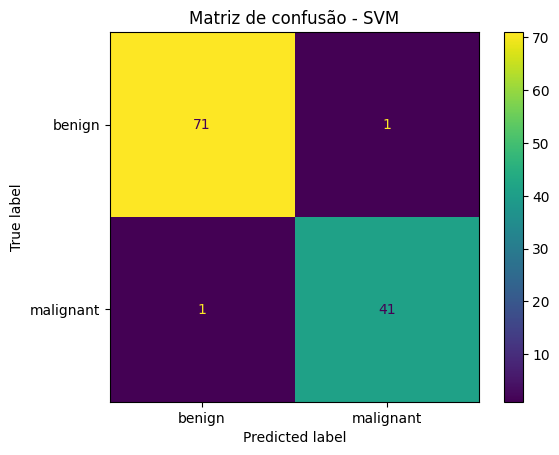

In [ ]:
# Matriz de confusão do melhor modelo
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["benign", "malignant"]
)

disp.plot(values_format="d")
plt.title(f"Matriz de confusão - {best_model_name}")
plt.show()

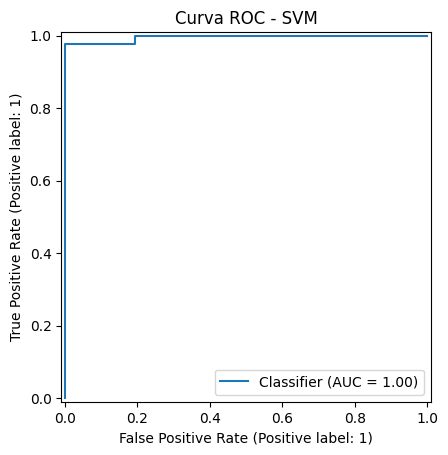

ROC-AUC: 0.9954


In [ ]:
# Curva ROC do melhor modelo
if hasattr(best_model, "predict_proba"):
    y_score_best = best_model.predict_proba(X_test)[:, 1]
else:
    y_score_best = best_model.decision_function(X_test)

RocCurveDisplay.from_predictions(y_test, y_score_best)
plt.title(f"Curva ROC - {best_model_name}")
plt.show()

print(f"ROC-AUC: {roc_auc_score(y_test, y_score_best):.4f}")

## 9. Análise dos resultados

Nesta seção, analiso os principais resultados obtidos após a validação cruzada, a otimização de hiperparâmetros e a avaliação final no conjunto de teste.

De forma geral, os modelos de Machine Learning apresentaram desempenho muito superior ao baseline. O baseline utilizado foi um `DummyClassifier`, que sempre prevê a classe mais frequente. Como a classe benigna é majoritária na base, esse modelo atingiu acurácia de aproximadamente **63,16%** no teste, mas teve **recall igual a 0,00 para a classe maligna**. Isso mostra que a acurácia isoladamente seria uma métrica insuficiente para este problema, já que um modelo poderia parecer razoável apenas por prever a classe majoritária, mesmo sem identificar nenhum tumor maligno.

Na validação cruzada, a **Regressão Logística** apresentou o melhor desempenho médio geral, com acurácia média de aproximadamente **97,36%**, F1-score médio de **96,40%** e ROC-AUC médio de **99,58%**. O **SVM padrão** também teve desempenho muito próximo, com acurácia média de **96,92%**, F1-score médio de **95,83%** e ROC-AUC médio de **99,48%**. Ambos os modelos apresentaram recall médio de aproximadamente **95,29%** para a classe maligna.

O **Random Forest** também superou amplamente o baseline, mas apresentou desempenho um pouco inferior aos modelos lineares/SVM na validação cruzada. Além disso, observei um possível sinal de overfitting: o F1-score médio de treino foi **1,00**, enquanto o F1-score médio de validação foi aproximadamente **94,95%**, gerando um gap de cerca de **5,05 pontos percentuais**. Isso sugere que o modelo aprendeu muito bem os padrões do conjunto de treino, mas generalizou um pouco pior do que os demais modelos.

Na etapa de otimização, o SVM foi ajustado com `GridSearchCV`. A melhor configuração encontrada foi:

- `C = 10`;
- `kernel = rbf`;
- `gamma = scale`.

Essa configuração atingiu recall médio de aproximadamente **96,47%** na validação cruzada, melhorando o recall em relação ao SVM padrão na etapa de validação. Como o recall da classe maligna é uma métrica especialmente importante neste problema, esse resultado foi relevante.

Entretanto, na avaliação final no conjunto de teste, o **SVM padrão** apresentou o melhor desempenho observado. Ele obteve:

- **Acurácia:** 98,25%;
- **Precisão:** 97,62%;
- **Recall:** 97,62%;
- **F1-score:** 97,62%;
- **ROC-AUC:** 99,54%.

A matriz de confusão do SVM padrão mostrou um resultado bastante positivo: o modelo classificou corretamente **71 de 72 tumores benignos** e **41 de 42 tumores malignos**. Houve apenas **1 falso positivo** e **1 falso negativo**.

Esse ponto é especialmente importante porque, no contexto do problema, o erro mais sensível é o falso negativo, isto é, classificar um tumor maligno como benigno. O SVM padrão apresentou apenas um caso desse tipo no conjunto de teste, o que indica boa capacidade de identificação dos casos malignos.

O **SVM otimizado**, apesar de ter apresentado melhor recall médio na validação cruzada, não superou o SVM padrão no teste. No conjunto de teste, ele obteve precisão de **100,00%**, mas recall de **92,86%**. Isso significa que, quando o modelo previu a classe maligna, ele acertou todos os casos previstos, mas deixou de identificar mais casos malignos do que o SVM padrão. Esse resultado mostra que a otimização de hiperparâmetros nem sempre garante melhora em dados não vistos, especialmente em datasets pequenos.

A **Regressão Logística** e o **Random Forest** também apresentaram bons resultados finais, ambos com acurácia de aproximadamente **96,49%**. No entanto, seus recalls para a classe maligna foram inferiores ao do SVM padrão. A Regressão Logística atingiu recall de **92,86%**, enquanto o Random Forest atingiu recall de **90,48%**.

Com base nesses resultados, considero que o **SVM padrão foi o modelo com melhor desempenho observado no conjunto de teste**, pois apresentou o melhor equilíbrio entre acurácia, precisão, recall, F1-score e ROC-AUC. Além disso, foi o modelo que melhor identificou os tumores malignos no teste, mantendo baixo número de falsos positivos e falsos negativos.

### Discussão sobre overfitting e underfitting

Não observei sinais relevantes de underfitting nos modelos principais, pois Regressão Logística, SVM e Random Forest apresentaram desempenho elevado tanto na validação cruzada quanto no teste.

Em relação ao overfitting, o principal ponto de atenção foi o Random Forest, que obteve F1-score perfeito no treino, mas desempenho menor na validação. Esse comportamento indica que o modelo pode ter se ajustado demais ao conjunto de treino. Ainda assim, o desempenho final no teste continuou alto, então esse sinal não invalida o modelo, apenas mostra que ele foi menos equilibrado do que o SVM e a Regressão Logística.

### Limitações da análise

Apesar dos bons resultados, este MVP possui algumas limitações. O dataset é pequeno e bastante conhecido, o que facilita a obtenção de métricas elevadas. Além disso, a avaliação foi feita em apenas uma divisão treino/teste, ainda que acompanhada de validação cruzada no treino. Em um cenário real, seria necessário validar o modelo em outras bases independentes e com acompanhamento de especialistas da área médica.

Também é importante reforçar que este trabalho tem finalidade acadêmica e não deve ser interpretado como uma ferramenta clínica pronta para uso. Para aplicação real, seriam necessárias validações externas, análise de robustez, interpretabilidade, calibração das probabilidades e avaliação regulatória.

In [ ]:
# Importância de atributos para Random Forest, caso o modelo exista na lista
rf_model = fitted_models["Random Forest"]
rf_importances = rf_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "atributo": X_train.columns,
    "importancia": rf_importances
}).sort_values("importancia", ascending=False)

feature_importance_df.head(10)

,atributo,importancia
22,perimeter_worst,0.150188
23,area_worst,0.135993
27,concave points_worst,0.105086
7,concave points_mean,0.101816
20,radius_worst,0.068266
2,perimeter_mean,0.057941
6,concavity_mean,0.053002
0,radius_mean,0.050573
26,concavity_worst,0.039171
3,area_mean,0.038296


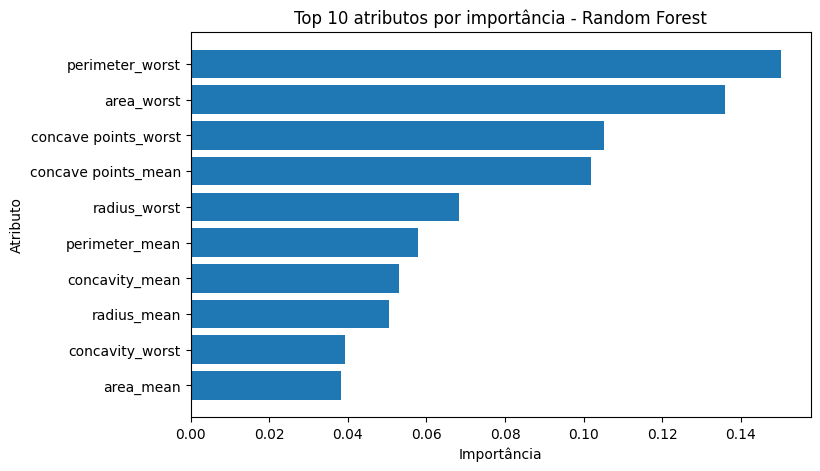

In [ ]:
# Gráfico de importância dos 10 principais atributos segundo Random Forest
top_features = feature_importance_df.head(10).sort_values("importancia")

plt.figure(figsize=(8, 5))
plt.barh(top_features["atributo"], top_features["importancia"])
plt.title("Top 10 atributos por importância - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Atributo")
plt.show()

## 10. Checklist do MVP

### Definição do problema

- **Qual é a descrição do problema?**  
  Classificar tumores de mama como benignos ou malignos a partir de atributos numéricos extraídos de imagens de células.

- **Qual é o objetivo do modelo?**  
  O objetivo foi construir um modelo capaz de identificar corretamente tumores malignos e benignos, com atenção especial ao recall da classe maligna, já que falsos negativos são erros mais críticos nesse contexto.

- **O problema é de classificação, regressão, clusterização, previsão de séries temporais ou outro tipo?**  
  É um problema de classificação supervisionada binária.

- **Por que esse problema pode ser resolvido com Machine Learning?**  
  Porque há uma base histórica rotulada, com atributos numéricos dos tumores e diagnóstico conhecido. A partir desses exemplos, os algoritmos conseguem aprender padrões associados às classes benigna e maligna.

- **Você tem premissas ou hipóteses sobre o problema?**  
  Sim. A principal hipótese é que as características numéricas extraídas dos núcleos celulares possuem relação relevante com o diagnóstico do tumor.

- **Que restrições ou condições foram consideradas na escolha dos dados?**  
  A base precisava ser pública, reproduzível, pequena o suficiente para rodar rapidamente no Colab e carregável sem login, token, chave de API ou upload manual.

### Descrição dos dados

- **Qual dataset foi utilizado?**  
  Foi utilizado o Breast Cancer Wisconsin Diagnostic Dataset.

- **Qual é a fonte dos dados?**  
  O dataset é público e foi originalmente disponibilizado pelo UCI Machine Learning Repository, também estando disponível em bibliotecas públicas de Machine Learning.

- **Como os dados foram carregados no notebook?**  
  Os dados foram carregados por meio de URL pública, com fallback usando a biblioteca `scikit-learn`.

- **Quantos registros e atributos existem?**  
  A base utilizada possui **569 registros** e **30 atributos preditores numéricos**, além das colunas associadas ao alvo.

- **Quais são os principais atributos?**  
  Os principais atributos descrevem características dos núcleos celulares, como raio, textura, perímetro, área, suavidade, compacidade, concavidade, pontos côncavos, simetria e dimensão fractal.

- **Existe variável-alvo? Se sim, qual?**  
  Sim. A variável-alvo é o diagnóstico do tumor, padronizado neste notebook como `target_malignant`, em que 1 representa tumor maligno e 0 representa tumor benigno.

- **Há limitações conhecidas no dataset?**  
  Sim. É uma base pequena e clássica, adequada para fins acadêmicos, mas insuficiente para validar uma solução clínica real sem testes externos.

### Preparação dos dados

- **Houve valores ausentes? Como foram tratados?**  
  Não foram encontrados valores ausentes no dataset analisado.

- **Houve necessidade de remover ou transformar atributos?**  
  Sim. Colunas de índice ou identificação foram removidas quando aplicável, e a variável de diagnóstico foi padronizada.

- **Foram criados novos atributos?**  
  Foi criada a variável binária `target_malignant`, indicando se o tumor é maligno.

- **Foram aplicadas normalização, padronização, codificação ou outras transformações?**  
  Sim. Foi aplicada padronização com `StandardScaler` nos modelos sensíveis à escala, como Regressão Logística e SVM.

- **Houve preocupação com vazamento de dados?**  
  Sim. As transformações foram aplicadas dentro de pipelines, garantindo que o ajuste do pré-processamento ocorresse apenas com os dados de treino.

- **As transformações foram aplicadas de forma adequada à divisão treino/teste?**  
  Sim. O `StandardScaler` foi incluído nos pipelines e, portanto, não foi ajustado diretamente sobre a base completa.

### Divisão dos dados

- **Como os dados foram separados?**  
  Os dados foram separados em treino e teste.

- **Foi usada divisão treino/teste?**  
  Sim. Foi usada divisão de 80% para treino e 20% para teste.

- **Foi usada validação ou validação cruzada?**  
  Sim. Foi usada validação cruzada estratificada com 5 folds no conjunto de treino.

- **A estratégia de divisão é adequada para o tipo de problema?**  
  Sim. Como se trata de classificação supervisionada binária, a divisão estratificada ajudou a preservar a proporção entre tumores benignos e malignos.

- **No caso de séries temporais, a ordem temporal foi respeitada?**  
  Não se aplica, pois o problema não é de série temporal.

- **No caso de clusterização, como a avaliação foi planejada?**  
  Não se aplica, pois o problema não é de clusterização.

### Modelagem

- **Qual foi o baseline utilizado?**  
  O baseline foi um `DummyClassifier` com estratégia de classe mais frequente.

- **Quais modelos foram treinados?**  
  Foram treinados Regressão Logística, Random Forest, SVM padrão e SVM otimizado.

- **Por que esses modelos foram escolhidos?**  
  A Regressão Logística foi escolhida como modelo simples e interpretável; o Random Forest, por capturar relações não lineares; e o SVM, por ser uma abordagem forte para classificação binária com atributos numéricos padronizados.

- **Os modelos foram comparados de forma justa?**  
  Sim. Todos foram avaliados usando a mesma divisão treino/teste e validação cruzada estratificada no conjunto de treino.

- **Foi observado algum indício de underfitting?**  
  Não houve indício relevante de underfitting nos modelos principais, pois eles apresentaram desempenho alto na validação e no teste.

- **Algum modelo apresentou sinais de overfitting?**  
  O Random Forest apresentou leve sinal de overfitting, pois teve F1-score perfeito no treino e desempenho menor na validação. Ainda assim, seu resultado no teste foi bom.

### Otimização

- **Algum modelo teve hiperparâmetros ajustados?**  
  Sim. O SVM foi otimizado com `GridSearchCV`.

- **Quais hiperparâmetros foram escolhidos?**  
  Foram ajustados `C`, `kernel` e `gamma`.

- **Qual estratégia de busca foi usada?**  
  Foi usada busca em grade com validação cruzada estratificada.

- **O ajuste trouxe melhora em relação à versão inicial?**  
  O ajuste melhorou o recall médio na validação cruzada, chegando a aproximadamente **96,47%**. Porém, no conjunto de teste, o SVM padrão apresentou melhor equilíbrio geral e maior recall do que o SVM otimizado.

- **A otimização foi feita sem usar indevidamente os dados de teste?**  
  Sim. A otimização foi feita apenas no conjunto de treino, usando validação cruzada.

### Avaliação

- **Quais métricas foram utilizadas?**  
  Foram usadas acurácia, precisão, recall, F1-score, ROC-AUC, relatório de classificação e matriz de confusão.

- **Por que essas métricas são adequadas?**  
  Porque o problema é de classificação binária. O recall foi especialmente importante porque falsos negativos, isto é, tumores malignos classificados como benignos, são erros mais críticos.

- **Qual modelo teve melhor desempenho?**  
  O SVM padrão teve o melhor desempenho observado no conjunto de teste, com acurácia de **98,25%**, recall de **97,62%**, F1-score de **97,62%** e ROC-AUC de **99,54%**.

- **Os resultados fazem sentido para o problema?**  
  Sim. Os modelos reais superaram amplamente o baseline e apresentaram alta capacidade de separação entre as classes.

- **Houve análise de erros?**  
  Sim. A matriz de confusão do SVM padrão mostrou apenas **1 falso positivo** e **1 falso negativo** no conjunto de teste.

- **Quais são as principais limitações da solução?**  
  As principais limitações são o tamanho reduzido do dataset, a ausência de validação externa e o fato de o MVP ter finalidade acadêmica, não clínica.

### Conclusão

- **Qual foi a melhor solução encontrada?**  
  A melhor solução observada no teste foi o SVM padrão.

- **Por que ela foi escolhida?**  
  Porque apresentou o melhor equilíbrio entre acurácia, precisão, recall, F1-score e ROC-AUC, além de apenas um falso negativo no teste.

- **O MVP cumpriu o objetivo definido no início?**  
  Sim. O MVP demonstrou um fluxo completo de Machine Learning, desde a definição do problema até a avaliação crítica dos modelos.

- **Quais seriam os próximos passos para melhorar o projeto?**  
  Os próximos passos seriam validar o modelo em bases externas, explorar interpretabilidade, calibrar probabilidades, avaliar diferentes limiares de decisão e envolver especialistas do domínio.

## 11. Conclusão

Neste MVP, desenvolvi uma solução de Machine Learning para classificar tumores de mama como benignos ou malignos a partir do Breast Cancer Wisconsin Diagnostic Dataset.

O problema foi tratado como uma tarefa de classificação supervisionada binária. A variável-alvo foi padronizada para indicar se o tumor é maligno, e os atributos preditores foram compostos por 30 medidas numéricas extraídas de imagens de núcleos celulares. A base analisada possui 569 registros, sem valores ausentes, e apresenta uma distribuição de aproximadamente 62,74% de casos benignos e 37,26% de casos malignos.

Durante a preparação dos dados, removi colunas de identificação ou índice quando necessário, transformei o diagnóstico em uma variável binária e dividi os dados em treino e teste com estratificação. Também utilizei pipelines para garantir que a padronização fosse ajustada apenas nos dados de treino, evitando vazamento de dados.

Foram avaliados quatro tipos de abordagem: um baseline simples com `DummyClassifier`, Regressão Logística, Random Forest e SVM. O baseline teve desempenho limitado, com acurácia de 63,16% no teste e recall igual a zero para tumores malignos. Esse resultado mostrou que apenas prever a classe majoritária não resolve o problema, principalmente porque o objetivo mais importante é identificar corretamente os casos malignos.

Na validação cruzada, a Regressão Logística apresentou o melhor desempenho médio geral, com F1-score de aproximadamente 96,40% e ROC-AUC de 99,58%. O SVM padrão teve resultado muito próximo, com F1-score médio de 95,83% e ROC-AUC de 99,48%. O Random Forest também teve bom desempenho, mas apresentou um leve sinal de overfitting, pois atingiu F1-score perfeito no treino e desempenho menor na validação.

A otimização de hiperparâmetros foi realizada no SVM usando `GridSearchCV`. A melhor configuração encontrada foi `C = 10`, `kernel = rbf` e `gamma = scale`, com recall médio de 96,47% na validação cruzada. Apesar dessa melhora na validação, o SVM otimizado não foi o melhor modelo no conjunto de teste, pois apresentou recall de 92,86%, inferior ao SVM padrão.

No conjunto de teste, o melhor desempenho observado foi o do **SVM padrão**, que alcançou acurácia de **98,25%**, precisão de **97,62%**, recall de **97,62%**, F1-score de **97,62%** e ROC-AUC de **99,54%**. A matriz de confusão mostrou que o modelo acertou 71 de 72 casos benignos e 41 de 42 casos malignos, gerando apenas 1 falso positivo e 1 falso negativo.

Com base nesses resultados, considero o SVM padrão a melhor solução deste MVP, pois ele apresentou o melhor equilíbrio entre desempenho geral e identificação correta dos tumores malignos. Esse ponto é importante porque, neste problema, um falso negativo representa um erro mais crítico: classificar um tumor maligno como benigno.

O MVP cumpriu o objetivo definido no início, pois apresentou um fluxo completo de Machine Learning: definição do problema, carregamento dos dados, análise exploratória, preparação, divisão treino/teste, modelagem, otimização, avaliação e discussão crítica dos resultados.

Apesar dos resultados elevados, é importante reconhecer as limitações do trabalho. O dataset é pequeno, clássico e adequado para fins acadêmicos, mas não representa sozinho a complexidade de um ambiente clínico real. Além disso, a validação foi feita apenas dentro da própria base, sem teste em datasets externos. Por isso, os resultados devem ser interpretados como uma demonstração técnica de Machine Learning, e não como uma ferramenta médica pronta para uso.

Como próximos passos, eu recomendaria validar o modelo em bases externas, explorar técnicas de interpretabilidade, analisar a importância das variáveis com maior profundidade, calibrar as probabilidades previstas e avaliar diferentes limiares de decisão para reduzir ainda mais o risco de falsos negativos.

## 12. Informações de reprodutibilidade

- Seed utilizada: `42`.
- Ambiente esperado: Google Colab.
- Bibliotecas principais: pandas, numpy, matplotlib e scikit-learn.
- O notebook foi organizado para executar do início ao fim sem necessidade de upload manual, login, token ou chave de API.
- Caso a URL pública do dataset seja substituída por uma URL raw do GitHub do aluno, a execução permanece equivalente.